In [1]:
! pip install remotezip tqdm opencv-python einops
! pip install -U tensorflow keras

In [2]:
import tqdm
import random
import pathlib
import itertools
import collections
import zipfile
import os
import requests
import cv2
import einops
import numpy as np
import remotezip as rz
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers

In [3]:
HEIGHT = 224
WIDTH = 224
n_frames = 10
batch_size = 8

# Load and preprocess video data

In [4]:
def list_files_per_class(zip_url):
  """
    List the files in each class of the dataset given the zip URL.

    Args:
      zip_url: URL from which the files can be unzipped. 

    Return:
      files: List of files in each of the classes.
  """
  files = []
  with rz.RemoteZip(URL) as zip:
    for zip_info in zip.infolist():
      files.append(zip_info.filename)
  return files

def get_class(fname):
  """
    Retrieve the name of the class given a filename.

    Args:
      fname: Name of the file in the UCF101 dataset.

    Return:
      Class that the file belongs to.
  """
  return fname.split('_')[-3]

def get_files_per_class(files):
  """
    Retrieve the files that belong to each class. 

    Args:
      files: List of files in the dataset.

    Return:
      Dictionary of class names (key) and files (values).
  """
  files_for_class = collections.defaultdict(list)
  for fname in files:
    class_name = get_class(fname)
    files_for_class[class_name].append(fname)
  return files_for_class

def download_from_zip(zip_url, to_dir, file_names):
  """
    Download the contents of the zip file from the zip URL.

    Args:
      zip_url: Zip URL containing data.
      to_dir: Directory to download data to.
      file_names: Names of files to download.
  """
  with rz.RemoteZip(zip_url) as zip:
    for fn in tqdm.tqdm(file_names):
      class_name = get_class(fn)
      zip.extract(fn, str(to_dir / class_name))
      unzipped_file = to_dir / class_name / fn

      fn = pathlib.Path(fn).parts[-1]
      output_file = to_dir / class_name / fn
      unzipped_file.rename(output_file,)

def split_class_lists(files_for_class, count):
  """
    Returns the list of files belonging to a subset of data as well as the remainder of
    files that need to be downloaded.

    Args:
      files_for_class: Files belonging to a particular class of data.
      count: Number of files to download.

    Return:
      split_files: Files belonging to the subset of data.
      remainder: Dictionary of the remainder of files that need to be downloaded.
  """
  split_files = []
  remainder = {}
  for cls in files_for_class:
    split_files.extend(files_for_class[cls][:count])
    remainder[cls] = files_for_class[cls][count:]
  return split_files, remainder

def download_ufc_101_subset(zip_url, num_classes, splits, download_dir):
  """
    Download a subset of the UFC101 dataset and split them into various parts, such as
    training, validation, and test. 

    Args:
      zip_url: Zip URL containing data.
      num_classes: Number of labels.
      splits: Dictionary specifying the training, validation, test, etc. (key) division of data 
              (value is number of files per split).
      download_dir: Directory to download data to.

    Return:
      dir: Posix path of the resulting directories containing the splits of data.
  """
  files = list_files_per_class(zip_url)
  for f in files:
    tokens = f.split('/')
    if len(tokens) <= 2:
      files.remove(f) # Remove that item from the list if it does not have a filename

  files_for_class = get_files_per_class(files)

  classes = list(files_for_class.keys())[:num_classes]

  for cls in classes:
    new_files_for_class = files_for_class[cls]
    random.shuffle(new_files_for_class)
    files_for_class[cls] = new_files_for_class

  # Only use the number of classes you want in the dictionary
  files_for_class = {x: files_for_class[x] for x in list(files_for_class)[:num_classes]}

  dirs = {}
  for split_name, split_count in splits.items():
    print(split_name, ":")
    split_dir = download_dir / split_name
    split_files, files_for_class = split_class_lists(files_for_class, split_count)
    download_from_zip(zip_url, split_dir, split_files)
    dirs[split_name] = split_dir

  return dirs

def format_frames(frame, output_size):
  """
    Pad and resize an image from a video.

    Args:
      frame: Image that needs to resized and padded. 
      output_size: Pixel size of the output frame image.

    Return:
      Formatted frame with padding of specified output size.
  """
  frame = tf.image.convert_image_dtype(frame, tf.float32)
  frame = tf.image.resize_with_pad(frame, *output_size)
  return frame

def frames_from_video_file(video_path, n_frames, output_size = (224,224), frame_step = 15):
  """
    Creates frames from each video file present for each category.

    Args:
      video_path: File path to the video.
      n_frames: Number of frames to be created per video file.
      output_size: Pixel size of the output frame image.

    Return:
      An NumPy array of frames in the shape of (n_frames, height, width, channels).
  """
  # Read each video frame by frame
  result = []
  src = cv2.VideoCapture(str(video_path))  

  video_length = src.get(cv2.CAP_PROP_FRAME_COUNT)

  need_length = 1 + (n_frames - 1) * frame_step

  if need_length > video_length:
    start = 0
  else:
    max_start = video_length - need_length
    start = random.randint(0, max_start + 1)

  src.set(cv2.CAP_PROP_POS_FRAMES, start)
  # ret is a boolean indicating whether read was successful, frame is the image itself
  ret, frame = src.read()
  result.append(format_frames(frame, output_size))

  for _ in range(n_frames - 1):
    for _ in range(frame_step):
      ret, frame = src.read()
    if ret:
      frame = format_frames(frame, output_size)
      result.append(frame)
    else:
      result.append(np.zeros_like(result[0]))
  src.release()
  result = np.array(result)[..., [2, 1, 0]]

  return result

class FrameGenerator:
  def __init__(self, path, n_frames, training = False):
    """ Returns a set of frames with their associated label. 

      Args:
        path: Video file paths.
        n_frames: Number of frames. 
        training: Boolean to determine if training dataset is being created.
    """
    self.path = path
    self.n_frames = n_frames
    self.training = training
    self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
    self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

  def get_files_and_class_names(self):
    video_paths = list(self.path.glob('*/*.avi'))
    classes = [p.parent.name for p in video_paths] 
    return video_paths, classes

  def __call__(self):
    video_paths, classes = self.get_files_and_class_names()

    pairs = list(zip(video_paths, classes))

    if self.training:
      random.shuffle(pairs)

    for path, name in pairs:
      video_frames = frames_from_video_file(path, self.n_frames) 
      label = self.class_ids_for_name[name] # Encode labels
      yield video_frames, label

In [5]:
URL = 'https://storage.googleapis.com/thumos14_files/UCF101_videos.zip'
download_dir = pathlib.Path('./UCF101_subset/')
subset_paths = download_ufc_101_subset(URL, 
                        num_classes = 10, 
                        splits = {"train": 30, "val": 10, "test": 10},
                        download_dir = download_dir)

train :


100%|██████████| 300/300 [00:18<00:00, 16.14it/s]


val :


100%|██████████| 100/100 [00:05<00:00, 17.51it/s]


test :


100%|██████████| 100/100 [00:09<00:00, 10.11it/s]


In [6]:
# Output signature definition
output_signature = (
    tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int16)
)

# Train dataset with repeat and prefetch
train_ds = tf.data.Dataset.from_generator(
    FrameGenerator(subset_paths['train'], n_frames, training=True),
    output_signature=output_signature
)
train_ds = train_ds.repeat()  # Add repeat
train_ds = train_ds.batch(batch_size)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)  # Add prefetch for better performance

# Validation dataset
val_ds = tf.data.Dataset.from_generator(
    FrameGenerator(subset_paths['val'], n_frames),
    output_signature=output_signature
)
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# Test dataset
test_ds = tf.data.Dataset.from_generator(
    FrameGenerator(subset_paths['test'], n_frames),
    output_signature=output_signature
)
test_ds = test_ds.batch(batch_size)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [7]:
# train_path="/kaggle/input/ucf101-action-recognition/train/"
# valid_path="/kaggle/input/ucf101-action-recognition/val/"
# test_path="/kaggle/input/ucf101-action-recognition/test/"

In [8]:
# import random
# import numpy as np
# import cv2
# import tensorflow as tf
# import pathlib

# def format_frames(frame, output_size):
#     frame = tf.image.convert_image_dtype(frame, tf.float32)
#     frame = tf.image.resize_with_pad(frame, *output_size)
#     return frame

# def frames_from_video_file(video_path, n_frames, output_size=(224, 224), frame_step=15):
#     result = []
#     src = cv2.VideoCapture(str(video_path))  
#     video_length = src.get(cv2.CAP_PROP_FRAME_COUNT)
#     need_length = 1 + (n_frames - 1) * frame_step
    
#     if need_length > video_length:
#         start = 0
#     else:
#         max_start = video_length - need_length
#         start = random.randint(0, max_start + 1)
    
#     src.set(cv2.CAP_PROP_POS_FRAMES, start)
#     ret, frame = src.read()
#     result.append(format_frames(frame, output_size))

#     for _ in range(n_frames - 1):
#         for _ in range(frame_step):
#             ret, frame = src.read()
#         if ret:
#             frame = format_frames(frame, output_size)
#             result.append(frame)
#         else:
#             result.append(np.zeros_like(result[0]))
    
#     src.release()
#     result = np.array(result)[..., [2, 1, 0]]
#     return result

# class FrameGenerator:
#     def __init__(self, path, n_frames, training=False):
#         self.path = pathlib.Path(path)
#         self.n_frames = n_frames
#         self.training = training
#         self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
#         self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))
        
#         self.video_paths, _ = self.get_files_and_class_names()
#         self.size = len(self.video_paths)
        
#     def get_files_and_class_names(self):
#         video_paths = list(self.path.glob('*/*.avi'))
#         classes = [p.parent.name for p in video_paths]
#         return video_paths, classes
    
#     def __call__(self):
#         video_paths, classes = self.get_files_and_class_names()
#         pairs = list(zip(video_paths, classes))
#         if self.training:
#             random.shuffle(pairs)
#         for path, name in pairs:
#             video_frames = frames_from_video_file(path, self.n_frames) 
#             label = self.class_ids_for_name[name]
#             yield video_frames, label


In [9]:
# train_generator = FrameGenerator(train_path, n_frames, training=True)
# val_generator = FrameGenerator(valid_path, n_frames)
# test_generator = FrameGenerator(test_path, n_frames)

In [10]:
# print(f"Training dataset size: {train_generator.size}")
# print(f"Validation dataset size: {val_generator.size}")
# print(f"Test dataset size: {test_generator.size}")

In [11]:
# output_signature = (
#     tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32),
#     tf.TensorSpec(shape=(), dtype=tf.int32)
# )

# train_ds = tf.data.Dataset.from_generator(
#     train_generator,
#     output_signature=output_signature
# ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# val_ds = tf.data.Dataset.from_generator(
#     val_generator,
#     output_signature=output_signature
# ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# test_ds = tf.data.Dataset.from_generator(
#     test_generator,
#     output_signature=output_signature
# ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [12]:
# train_generator = FrameGenerator(train_path, n_frames, training=True)
# class_names = train_generator.class_names
# label_length = len(class_names)
# print(f"Number of unique labels (classes): {label_length}")


In [13]:
# for video_frames, label in train_ds.take(1):
#     print("Label:", label)
#     print("Label data type:", type(label))
#     print("Is label integer?", np.issubdtype(label.numpy().dtype, np.integer))
#     print("Is label categorical?", isinstance(label.numpy(), str))


In [14]:
# steps_per_epoch = train_generator.size // batch_size
# validation_steps = val_generator.size // batch_size

# Create the model

* The following 3D convolutional neural network model is based off the paper A Closer Look at Spatiotemporal Convolutions for Action Recognition by D. Tran et al. (2017). The paper compares several versions of 3D ResNets. Instead of operating on a single image with dimensions (height, width), like standard ResNets, these operate on video volume (time, height, width). The most obvious approach to this problem would be replace each 2D convolution (layers.Conv2D) with a 3D convolution (layers.Conv3D).

* This tutorial uses a (2 + 1)D convolution with residual connections. The (2 + 1)D convolution allows for the decomposition of the spatial and temporal dimensions, therefore creating two separate steps. An advantage of this approach is that factorizing the convolutions into spatial and temporal dimensions saves parameters.

* For each output location a 3D convolution combines all the vectors from a 3D patch of the volume to create one vector in the output volume.

![](https://www.tensorflow.org/images/tutorials/video/3DCNN.png)

* This operation is takes time * height * width * channels inputs and produces channels outputs (assuming the number of input and output channels are the same. So a 3D convolution layer with a kernel size of (3 x 3 x 3) would need a weight-matrix with 27 * channels ** 2 entries. The reference paper found that a more effective & efficient approach was to factorize the convolution. Instead of a single 3D convolution to process the time and space dimensions, they proposed a "(2+1)D" convolution which processes the space and time dimensions separately. The figure below shows the factored spatial and temporal convolutions of a (2 + 1)D convolution.

![](https://www.tensorflow.org/images/tutorials/video/2plus1CNN.png)

* The main advantage of this approach is that it reduces the number of parameters. In the (2 + 1)D convolution the spatial convolution takes in data of the shape (1, width, height), while the temporal convolution takes in data of the shape (time, 1, 1). For example, a (2 + 1)D convolution with kernel size (3 x 3 x 3) would need weight matrices of size (9 * channels**2) + (3 * channels**2), less than half as many as the full 3D convolution. This tutorial implements (2 + 1)D ResNet18, where each convolution in the resnet is replaced by a (2+1)D convolution.

In [15]:
class Conv2Plus1D(keras.layers.Layer):
    
  def __init__(self, filters, kernel_size, padding):
    """
      A sequence of convolutional layers that first apply the convolution operation over the
      spatial dimensions, and then the temporal dimension. 
    """
    super().__init__()
    self.seq = keras.Sequential([  
        # Spatial decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(1, kernel_size[1], kernel_size[2]),
                      padding=padding),
        # Temporal decomposition
        layers.Conv3D(filters=filters, 
                      kernel_size=(kernel_size[0], 1, 1),
                      padding=padding)
        ])

  def call(self, x):
    return self.seq(x)

* A ResNet model is made from a sequence of residual blocks. A residual block has two branches. The main branch performs the calculation, but is difficult for gradients to flow through. The residual branch bypasses the main calculation and mostly just adds the input to the output of the main branch. Gradients flow easily through this branch. Therefore, an easy path from the loss function to any of the residual block's main branch will be present. This avoids the vanishing gradient problem.

* Create the main branch of the residual block with the following class. In contrast to the standard ResNet structure this uses the custom Conv2Plus1D layer instead of layers.Conv2D.

In [16]:
class ResidualMain(keras.layers.Layer):
  """
    Residual block of the model with convolution, layer normalization, and the
    activation function, ReLU.
  """
  def __init__(self, filters, kernel_size):
    super().__init__()
    self.seq = keras.Sequential([
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization(),
        layers.ReLU(),
        Conv2Plus1D(filters=filters, 
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

* To add the residual branch to the main branch it needs to have the same size. The Project layer below deals with cases where the number of channels is changed on the branch. In particular, a sequence of densely-connected layer followed by normalization is added.

In [17]:
class Project(keras.layers.Layer):
  """
    Project certain dimensions of the tensor as the data is passed through different 
    sized filters and downsampled. 
  """
  def __init__(self, units):
    super().__init__()
    self.seq = keras.Sequential([
        layers.Dense(units),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

* Use add_residual_block to introduce a skip connection between the layers of the model.

In [18]:
def add_residual_block(input, filters, kernel_size):
  """
    Add residual blocks to the model. If the last dimensions of the input data
    and filter size does not match, project it such that last dimension matches.
  """
  out = ResidualMain(filters, 
                     kernel_size)(input)

  res = input
  # Using the Keras functional APIs, project the last dimension of the tensor to
  # match the new filter size
  if out.shape[-1] != input.shape[-1]:
    res = Project(out.shape[-1])(res)

  return layers.add([res, out])

* Resizing the video is necessary to perform downsampling of the data. In particular, downsampling the video frames allow for the model to examine specific parts of frames to detect patterns that may be specific to a certain action. Through downsampling, non-essential information can be discarded. Moreoever, resizing the video will allow for dimensionality reduction and therefore faster processing through the model.

In [19]:
class ResizeVideo(keras.layers.Layer):
  def __init__(self, height, width):
    super().__init__()
    self.height = height
    self.width = width
    self.resizing_layer = layers.Resizing(self.height, self.width)

  def call(self, video):
    """
      Use the einops library to resize the tensor.  

      Args:
        video: Tensor representation of the video, in the form of a set of frames.

      Return:
        A downsampled size of the video according to the new height and width it should be resized to.
    """
    # b stands for batch size, t stands for time, h stands for height, 
    # w stands for width, and c stands for the number of channels.
    old_shape = einops.parse_shape(video, 'b t h w c')
    images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
    images = self.resizing_layer(images)
    videos = einops.rearrange(
        images, '(b t) h w c -> b t h w c',
        t = old_shape['t'])
    return videos

In [20]:
input_shape = (None, 10, HEIGHT, WIDTH, 3)
input = layers.Input(shape=(input_shape[1:]))
x = input

x = Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = ResizeVideo(HEIGHT // 2, WIDTH // 2)(x)

# Block 1
x = add_residual_block(x, 16, (3, 3, 3))
x = ResizeVideo(HEIGHT // 4, WIDTH // 4)(x)

# Block 2
x = add_residual_block(x, 32, (3, 3, 3))
x = ResizeVideo(HEIGHT // 8, WIDTH // 8)(x)

# Block 3
x = add_residual_block(x, 64, (3, 3, 3))
x = ResizeVideo(HEIGHT // 16, WIDTH // 16)(x)

# Block 4
x = add_residual_block(x, 128, (3, 3, 3))

x = layers.GlobalAveragePooling3D()(x)
x = layers.Flatten()(x)
x = layers.Dense(10)(x)

model = keras.Model(input, x)

In [21]:
frames, label = next(iter(train_ds))
model.build(frames)

# Visualize the model

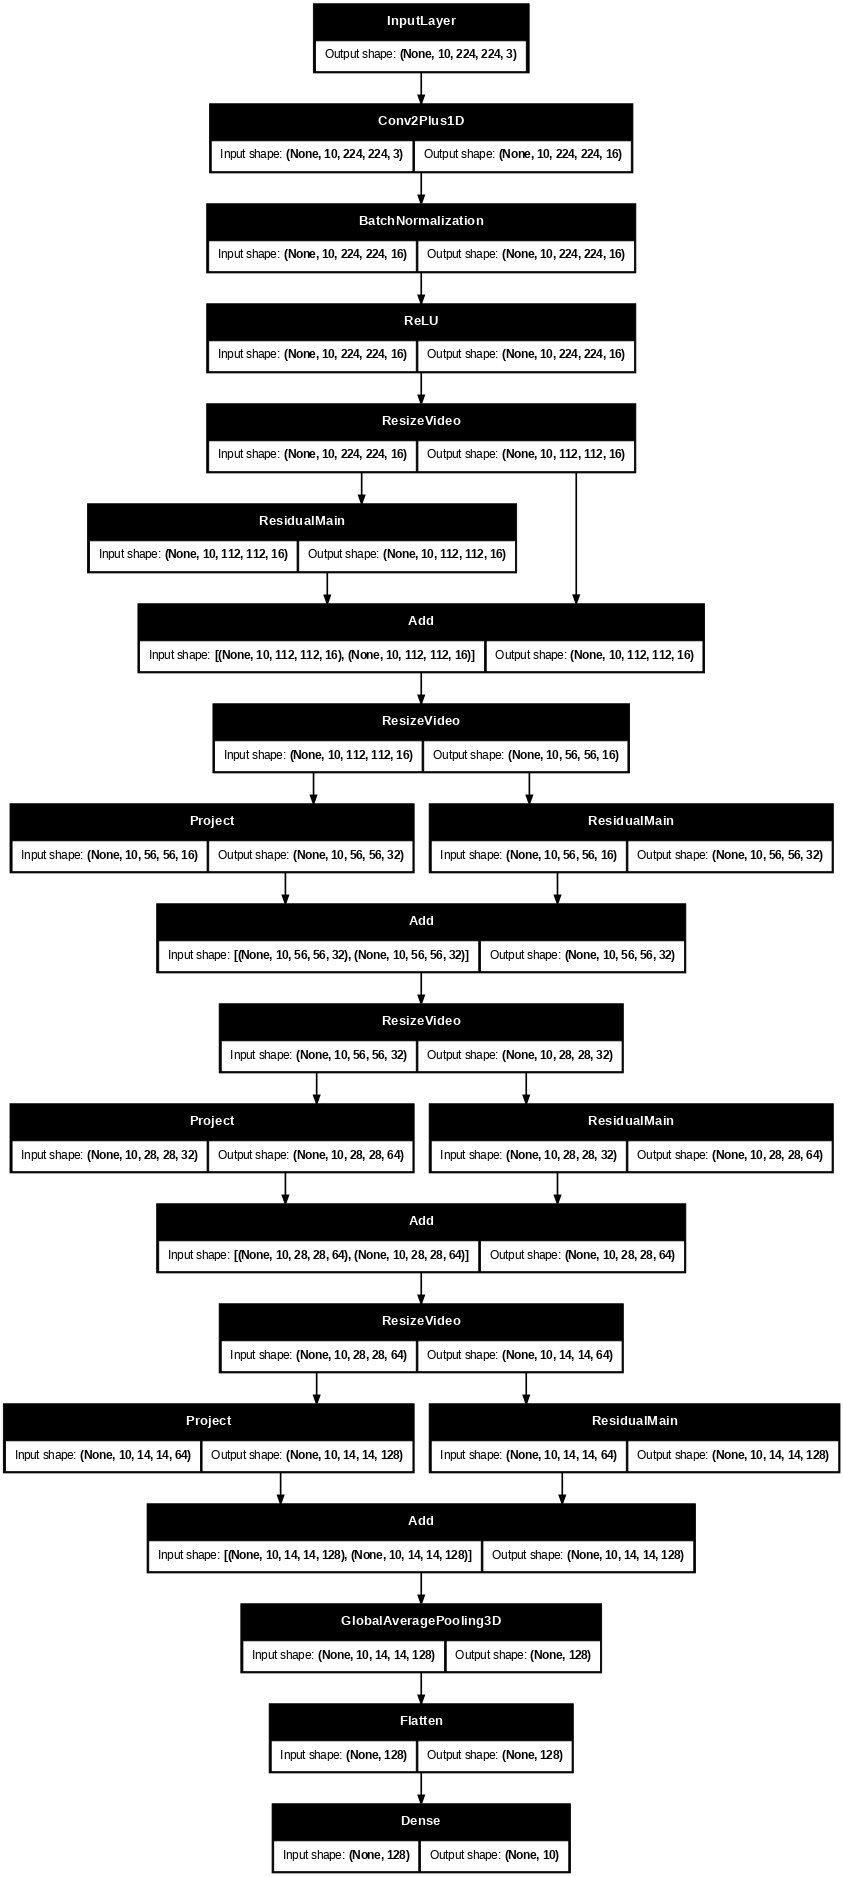

In [22]:

keras.utils.plot_model(model, expand_nested=True, dpi=60, show_shapes=True)

In [23]:
model.compile(loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
              optimizer = keras.optimizers.Adam(learning_rate = 0.001), 
              metrics = ['accuracy'])

model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 10, 224, 224,   │              0 │ -                      │
│                           │ 3)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_plus1d              │ (None, 10, 224, 224,   │          3,152 │ input_layer[0][0]      │
│ (Conv2Plus1D)             │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 10, 224, 224,   │             64 │ conv2_plus1d[0][0]     │
│ (BatchNormalization)      │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 10, 224, 224,   │              0 │ batch_normalization[0… │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resize_video              │ (None, 10, 112, 112,   │              0 │ re_lu[0][0]            │
│ (ResizeVideo)             │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ residual_main             │ (None, 10, 112, 112,   │          6,272 │ resize_video[0][0]     │
│ (ResidualMain)            │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 10, 112, 112,   │              0 │ resize_video[0][0],    │
│                           │ 16)                    │                │ residual_main[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resize_video_1            │ (None, 10, 56, 56, 16) │              0 │ add[0][0]              │
│ (ResizeVideo)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ project (Project)         │ (None, 10, 56, 56, 32) │            608 │ resize_video_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ residual_main_1           │ (None, 10, 56, 56, 32) │         20,224 │ resize_video_1[0][0]   │
│ (ResidualMain)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 10, 56, 56, 32) │              0 │ project[0][0],         │
│                           │                        │                │ residual_main_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resize_video_2            │ (None, 10, 28, 28, 32) │              0 │ add_1[0][0]            │
│ (ResizeVideo)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ project_1 (Project)       │ (None, 10, 28, 28, 64) │          2,240 │ resize_video_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ residual_main_2           │ (None, 10, 28, 28, 64) │         80,384 │ resize_video_2[0][0]   │
│ (ResidualMain)       

 Total params: 443,322 (1.69 MB)

 Trainable params: 443,290 (1.69 MB)

 Non-trainable params: 32 (128.00 B)

In [24]:
from pathlib import Path
import math

# Paths for train, validation, and test datasets
train_path = Path('/kaggle/working/UCF101_subset/train/')
val_path = Path('/kaggle/working/UCF101_subset/val/')


# Count the total number of video files in the train, val, and test directories
total_train_samples = sum(1 for _ in train_path.rglob('*.avi'))  # Adjust extension if needed
total_val_samples = sum(1 for _ in val_path.rglob('*.avi'))


# Define steps per epoch and validation steps
steps_per_epoch = math.ceil(total_train_samples / batch_size)
validation_steps = math.ceil(total_val_samples / batch_size)

# Output the results
print(f"Total train samples: {total_train_samples}")
print(f"Total validation samples: {total_val_samples}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")


Total train samples: 664
Total validation samples: 420
Steps per epoch: 83
Validation steps: 53


In [25]:
# history=model.fit(train_ds, 
#           validation_data=val_ds, 
#           epochs=40,
#           steps_per_epoch=steps_per_epoch, 
#           validation_steps=validation_steps)

In [26]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_history(history):
#     fig, (ax1, ax2) = plt.subplots(2)
#     fig.set_size_inches(18.5, 10.5)

#     ax1.set_title('Loss')
#     ax1.plot(history.history['loss'], label='Train', color='blue', linewidth=2)
#     ax1.plot(history.history['val_loss'], label='Validation', color='red', linestyle='--', linewidth=2)
#     ax1.set_ylabel('Loss')
#     max_loss = max(max(history.history['loss']), max(history.history['val_loss']))
#     ax1.set_ylim([0, np.ceil(max_loss)])
#     ax1.set_xlabel('Epoch')
#     ax1.legend(loc='upper right', fontsize=12)

#     ax2.set_title('Accuracy')
#     ax2.plot(history.history['accuracy'], label='Train', color='green', linewidth=2)
#     ax2.plot(history.history['val_accuracy'], label='Validation', color='orange', linestyle='--', linewidth=2)
#     ax2.set_ylabel('Accuracy')
#     ax2.set_ylim([0, 1])
#     ax2.set_xlabel('Epoch')
#     ax2.legend(loc='lower right', fontsize=12)

#     plt.tight_layout()
#     plt.show()

# plot_history(history)


In [27]:
# model.save('video_classifier_model.h5')

In [28]:
from tensorflow import keras
from tensorflow.keras import layers

class Conv2Plus1D(keras.layers.Layer):
    def __init__(self, filters, kernel_size, padding, **kwargs):
        """
        A sequence of convolutional layers that first apply the convolution operation
        over the spatial dimensions, and then the temporal dimension.
        """
        super(Conv2Plus1D, self).__init__(**kwargs)
        self.seq = keras.Sequential([
            # Spatial decomposition
            layers.Conv3D(filters=filters,
                          kernel_size=(1, kernel_size[1], kernel_size[2]),
                          padding=padding),
            # Temporal decomposition
            layers.Conv3D(filters=filters,
                          kernel_size=(kernel_size[0], 1, 1),
                          padding=padding)
        ])

    def call(self, x):
        return self.seq(x)

    def get_config(self):
        config = super(Conv2Plus1D, self).get_config()
        config.update({
            "filters": self.seq.layers[0].filters,
            "kernel_size": (
                self.seq.layers[1].kernel_size[0],
                self.seq.layers[0].kernel_size[1],
                self.seq.layers[0].kernel_size[2]
            ),
            "padding": self.seq.layers[0].padding,
        })
        return config


In [29]:
import einops

class ResizeVideo(keras.layers.Layer):
    def __init__(self, height, width, **kwargs):
        """
        Custom layer to resize video frames using einops and the Resizing layer.
        """
        super(ResizeVideo, self).__init__(**kwargs)
        self.height = height
        self.width = width
        self.resizing_layer = layers.Resizing(self.height, self.width)

    def call(self, video):
        """
        Resize a tensor representing video frames.
        """
        old_shape = einops.parse_shape(video, 'b t h w c')
        images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
        images = self.resizing_layer(images)
        videos = einops.rearrange(
            images, '(b t) h w c -> b t h w c',
            t=old_shape['t']
        )
        return videos

    def get_config(self):
        """
        Returns the config of the layer for serialization.
        """
        config = super(ResizeVideo, self).get_config()
        config.update({
            "height": self.height,
            "width": self.width,
        })
        return config


In [30]:
class ResidualMain(keras.layers.Layer):
    """
    Residual block of the model with convolution, layer normalization, 
    and the activation function ReLU.
    """
    def __init__(self, filters, kernel_size, **kwargs):
        super(ResidualMain, self).__init__(**kwargs)
        self.seq = keras.Sequential([
            Conv2Plus1D(filters=filters,
                        kernel_size=kernel_size,
                        padding='same'),
            layers.LayerNormalization(),
            layers.ReLU(),
            Conv2Plus1D(filters=filters,
                        kernel_size=kernel_size,
                        padding='same'),
            layers.LayerNormalization()
        ])

    def call(self, x):
        return self.seq(x)

    def get_config(self):
        """
        Returns the config of the layer for serialization.
        """
        config = super(ResidualMain, self).get_config()
        config.update({
            "filters": self.seq.layers[0].seq.layers[0].filters,
            "kernel_size": self.seq.layers[0].seq.layers[0].kernel_size,
        })
        return config


In [31]:
class Project(keras.layers.Layer):
    """
    Project certain dimensions of the tensor as the data is passed through 
    different sized filters and downsampled.
    """
    def __init__(self, units, **kwargs):
        super(Project, self).__init__(**kwargs)
        self.seq = keras.Sequential([
            layers.Dense(units),
            layers.LayerNormalization()
        ])

    def call(self, x):
        return self.seq(x)

    def get_config(self):
        """
        Returns the config of the layer for serialization.
        """
        config = super(Project, self).get_config()
        config.update({
            "units": self.seq.layers[0].units,
        })
        return config


In [32]:
from tensorflow.keras.models import load_model

# Register all custom layers
loaded_model = load_model(
    '/kaggle/working/video_classifier_model.h5',
    custom_objects={
        'Conv2Plus1D': Conv2Plus1D,
        'ResizeVideo': ResizeVideo,
        'ResidualMain': ResidualMain,
        'Project': Project
    }
)

# Verify the model structure
loaded_model.summary()


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 10, 224, 224,   │              0 │ -                      │
│                           │ 3)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_plus1d_9            │ (None, 10, 224, 224,   │          3,152 │ input_layer[0][0]      │
│ (Conv2Plus1D)             │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 10, 224, 224,   │             64 │ conv2_plus1d_9[0][0]   │
│ (BatchNormalization)      │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 10, 224, 224,   │              0 │ batch_normalization[0… │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resize_video_4            │ (None, 10, 112, 112,   │              0 │ re_lu[0][0]            │
│ (ResizeVideo)             │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ residual_main_4           │ (None, 10, 112, 112,   │          6,272 │ resize_video_4[0][0]   │
│ (ResidualMain)            │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 10, 112, 112,   │              0 │ resize_video_4[0][0],  │
│                           │ 16)                    │                │ residual_main_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resize_video_5            │ (None, 10, 56, 56, 16) │              0 │ add[0][0]              │
│ (ResizeVideo)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ project_3 (Project)       │ (None, 10, 56, 56, 32) │            608 │ resize_video_5[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ residual_main_5           │ (None, 10, 56, 56, 32) │         20,224 │ resize_video_5[0][0]   │
│ (ResidualMain)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 10, 56, 56, 32) │              0 │ project_3[0][0],       │
│                           │                        │                │ residual_main_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resize_video_6            │ (None, 10, 28, 28, 32) │              0 │ add_1[0][0]            │
│ (ResizeVideo)             │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ project_4 (Project)       │ (None, 10, 28, 28, 64) │          2,240 │ resize_video_6[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ residual_main_6           │ (None, 10, 28, 28, 64) │         80,384 │ resize_video_6[0][0]   │
│ (ResidualMain)       

 Total params: 443,324 (1.69 MB)

 Trainable params: 443,290 (1.69 MB)

 Non-trainable params: 32 (128.00 B)

 Optimizer params: 2 (12.00 B)

In [33]:
frame_gen = FrameGenerator(subset_paths['test'], n_frames)


test_ds_unbatched = tf.data.Dataset.from_generator(frame_gen,output_signature=output_signature)
n_samples = len(list(test_ds_unbatched.as_numpy_iterator()))

test_ds = tf.data.Dataset.from_generator(frame_gen,output_signature=output_signature)
test_ds = test_ds.batch(batch_size)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

steps = np.ceil(n_samples / batch_size).astype(int)

results = loaded_model.evaluate(test_ds,steps=steps,return_dict=True)

54/54 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.5230 - loss: 1.3433


54/54 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step


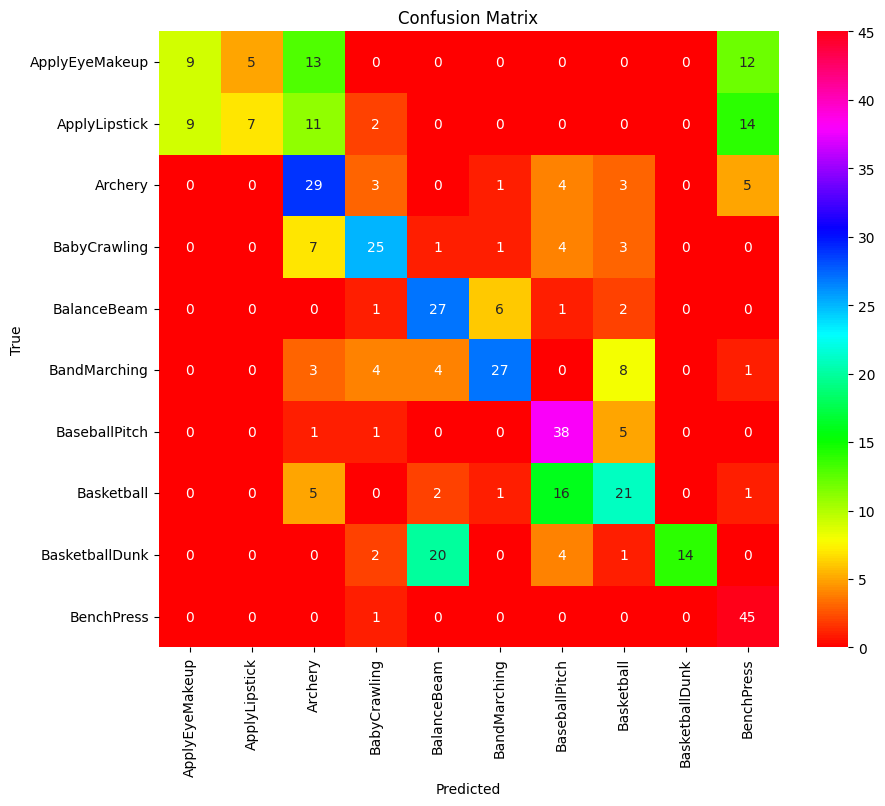

In [34]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve, 
    average_precision_score
)

predictions = loaded_model.predict(test_ds, steps=steps)
y_pred = np.argmax(predictions, axis=1)

test_ds_labels = []
for x, y in test_ds:
    test_ds_labels.extend(y.numpy())  
y_true = np.array(test_ds_labels)[:len(y_pred)]

class_dirs = sorted(subset_paths['train'].iterdir())
label_names = [p.name for p in class_dirs]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='hsv',xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



In [35]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_names))


Classification Report:
                precision    recall  f1-score   support

ApplyEyeMakeup       0.50      0.23      0.32        39
 ApplyLipstick       0.58      0.16      0.25        43
       Archery       0.42      0.64      0.51        45
  BabyCrawling       0.64      0.61      0.62        41
   BalanceBeam       0.50      0.73      0.59        37
  BandMarching       0.75      0.57      0.65        47
 BaseballPitch       0.57      0.84      0.68        45
    Basketball       0.49      0.46      0.47        46
BasketballDunk       1.00      0.34      0.51        41
    BenchPress       0.58      0.98      0.73        46

      accuracy                           0.56       430
     macro avg       0.60      0.56      0.53       430
  weighted avg       0.60      0.56      0.54       430



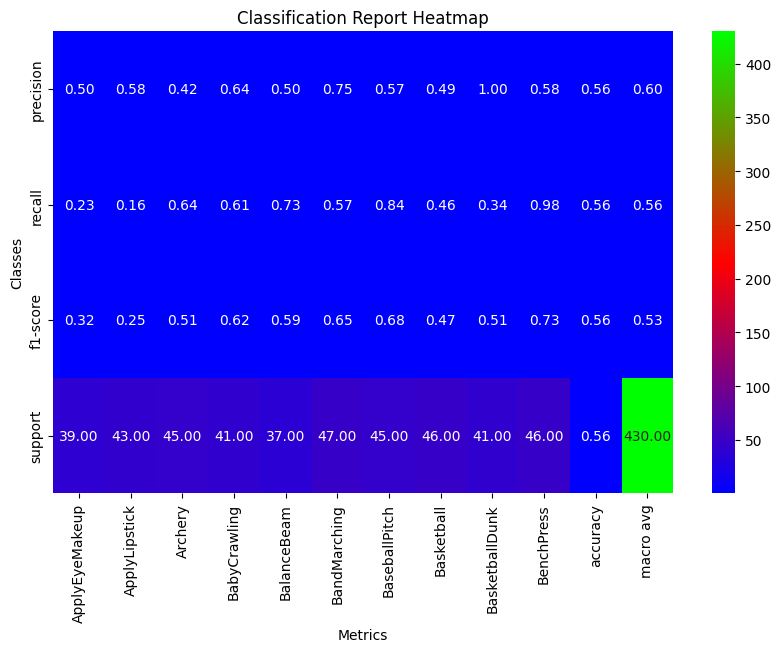

In [36]:
import pandas as pd
report_dict = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, fmt='.2f', cmap='brg', cbar=True)
plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')

plt.show()

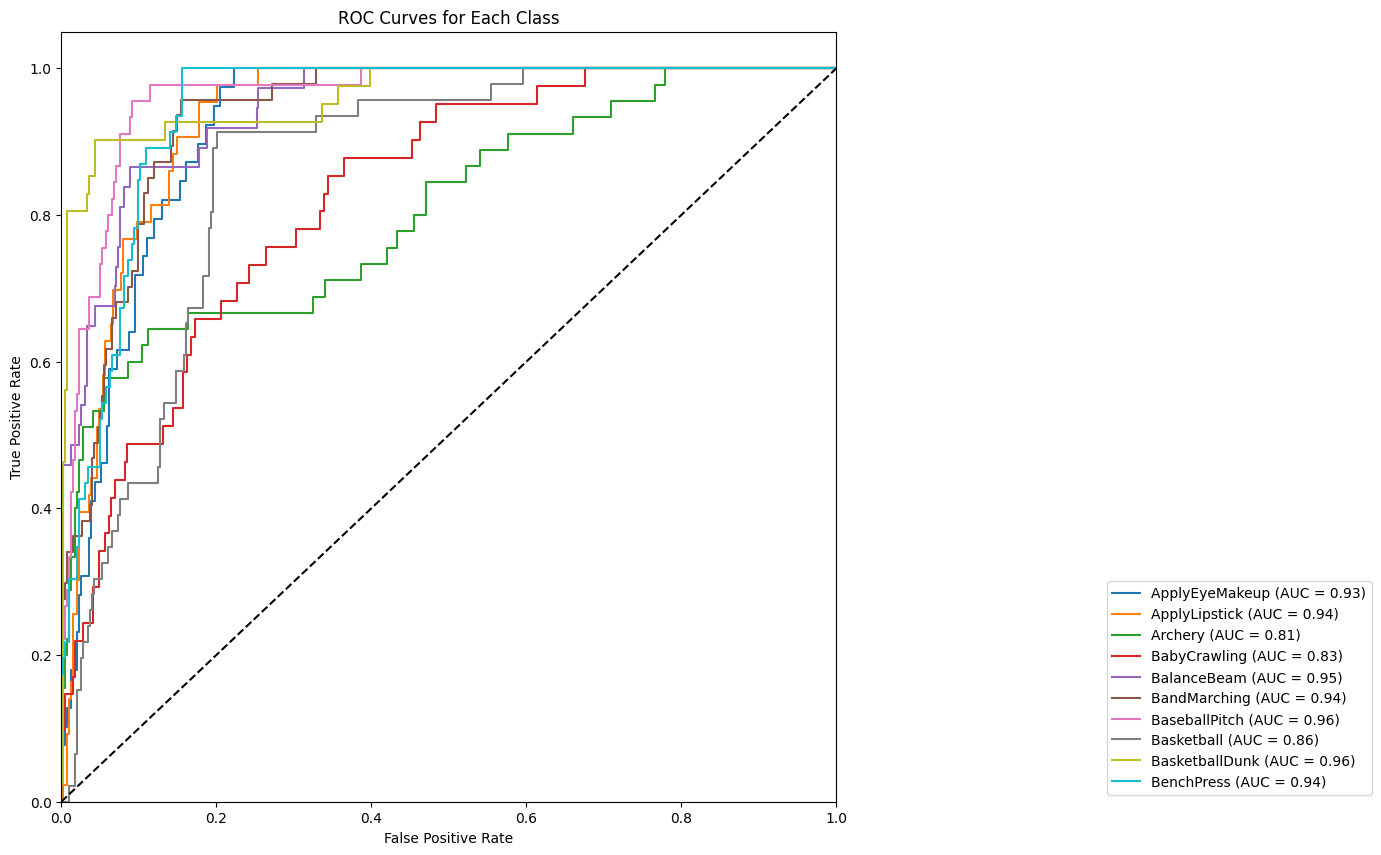

In [37]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 10))

y_test = tf.keras.utils.to_categorical(y_true)
y_pred_proba = predictions

for i in range(len(label_names)):
   fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
   roc_auc = auc(fpr, tpr)
   plt.plot(fpr, tpr, label=f'{label_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right", bbox_to_anchor=(1.7, 0))
plt.show()

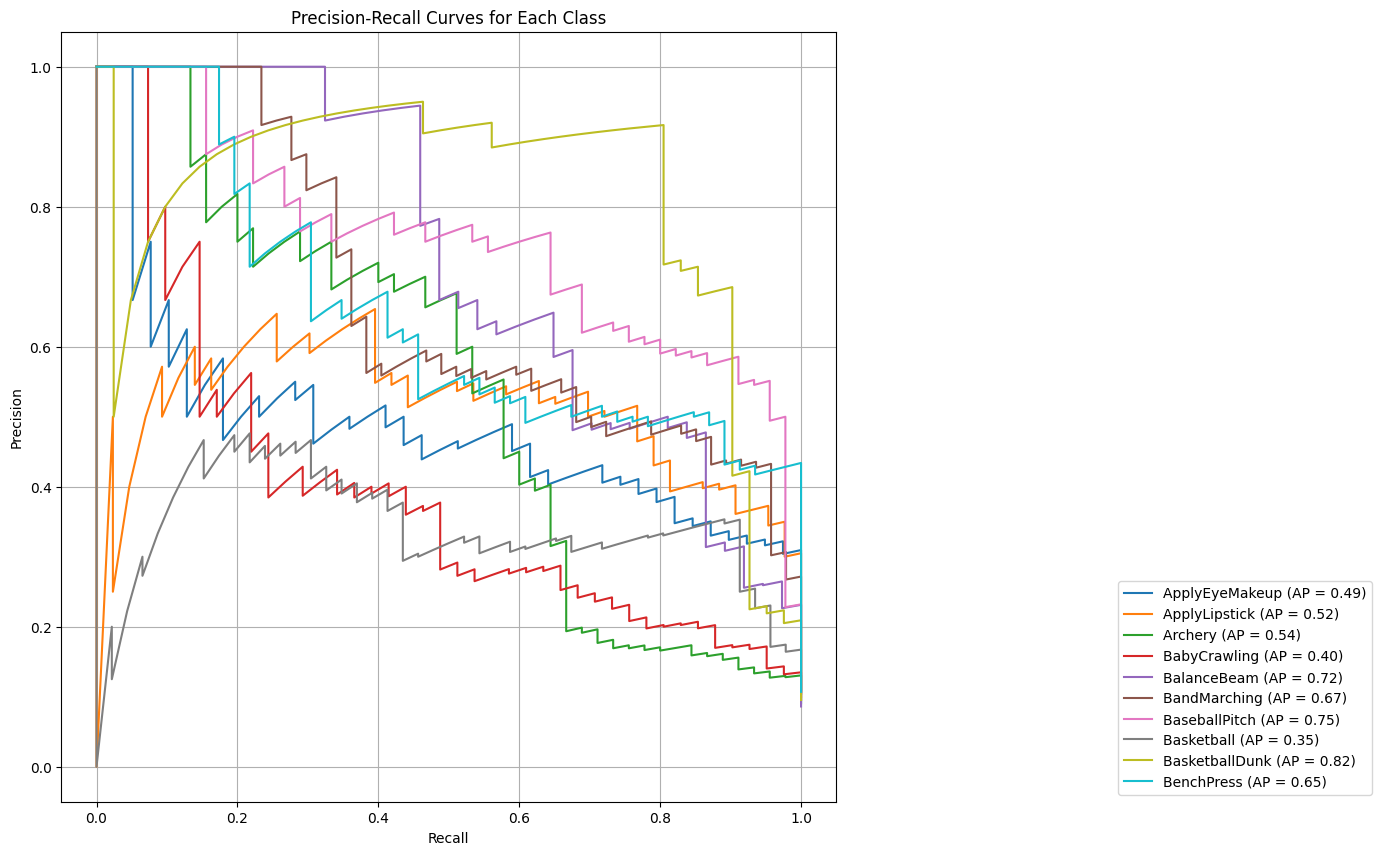

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 10))

for i in range(len(label_names)):
   precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_proba[:, i])
   ap = average_precision_score(y_test[:, i], y_pred_proba[:, i])
   plt.plot(recall, precision, label=f'{label_names[i]} (AP = {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Each Class')
plt.legend(loc="lower right", bbox_to_anchor=(1.7, 0))
plt.grid(True)
plt.show()

In [39]:
def prepare_single_video(frames):
    frames = frames[None, ...]
    return tf.cast(frames, tf.float32) / 255.0

def predict_action(path, n_frames=10):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = tf.image.resize(frame, [224, 224])
            frames.append(frame)
    finally:
        cap.release()
    
    frames = frames[:n_frames]
    if len(frames) < n_frames:
        frames = frames + [frames[-1]] * (n_frames - len(frames))
    
    frames = np.array(frames)
    frames = prepare_single_video(frames)
    
    prediction = loaded_model.predict(frames)
    
    # Apply softmax to get probabilities
    prediction = tf.nn.softmax(prediction).numpy()
    
    top3_idx = np.argsort(prediction[0])[-3:][::-1]
    for idx in top3_idx:
        print(f'{label_names[idx]}: {prediction[0][idx]*100:.2f}%')
    
    return frames, prediction

video_path = "/kaggle/working/UCF101_subset/test/Archery/v_Archery_g01_c06.avi"
frames, prediction = predict_action(video_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
Archery: 93.47%
ApplyLipstick: 4.31%
ApplyEyeMakeup: 1.42%


In [40]:
! pip install gradio

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [41]:
import gradio as gr

def process_video(video_path):
   frames, prediction = predict_action(video_path)
   prediction = tf.nn.softmax(prediction).numpy()
   
   results = []
   top3_idx = np.argsort(prediction[0])[-3:][::-1]
   for idx in top3_idx:
       results.append(f'{label_names[idx]}: {prediction[0][idx]*100:.2f}%')
   
   return '\n'.join(results)

demo = gr.Interface(
   fn=process_video,
   inputs=gr.Video(),
   outputs=gr.Textbox(label="Predictions"),
   title="Action Recognition",
   description="Upload a video to classify the action being performed."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
Kaggle notebooks require sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://b020ea74af89299f93.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
Archery: 81.95%
ApplyLipstick: 9.80%
BenchPress: 6.11%
